  CodeAlpha — TASK 1: Credit Scoring Model
EXPLORATORY DATA ANALYSIS
                       count      mean       std       min       25%  \
age                   5000.0     43.58     14.92     18.00     31.00   
income                5000.0  54756.64  19896.71  10000.00  41132.00   
loan_amount           5000.0  15006.49   7756.92   1000.00   9455.25   
debt_to_income_ratio  5000.0      0.33      0.16      0.05      0.20   
num_credit_lines      5000.0      7.55      4.03      1.00      4.00   
missed_payments       5000.0      4.59      2.85      0.00      2.00   
employment_years      5000.0     14.69      8.67      0.00      7.00   
credit_history_years  5000.0     12.36      6.90      1.00      6.00   
creditworthy          5000.0      0.49      0.50      0.00      0.00   

                           50%       75%       max  
age                      43.00     56.00      69.0  
income                54463.50  68227.50  120527.0  
loan_amount           14841.50  20326.50   43352.0 

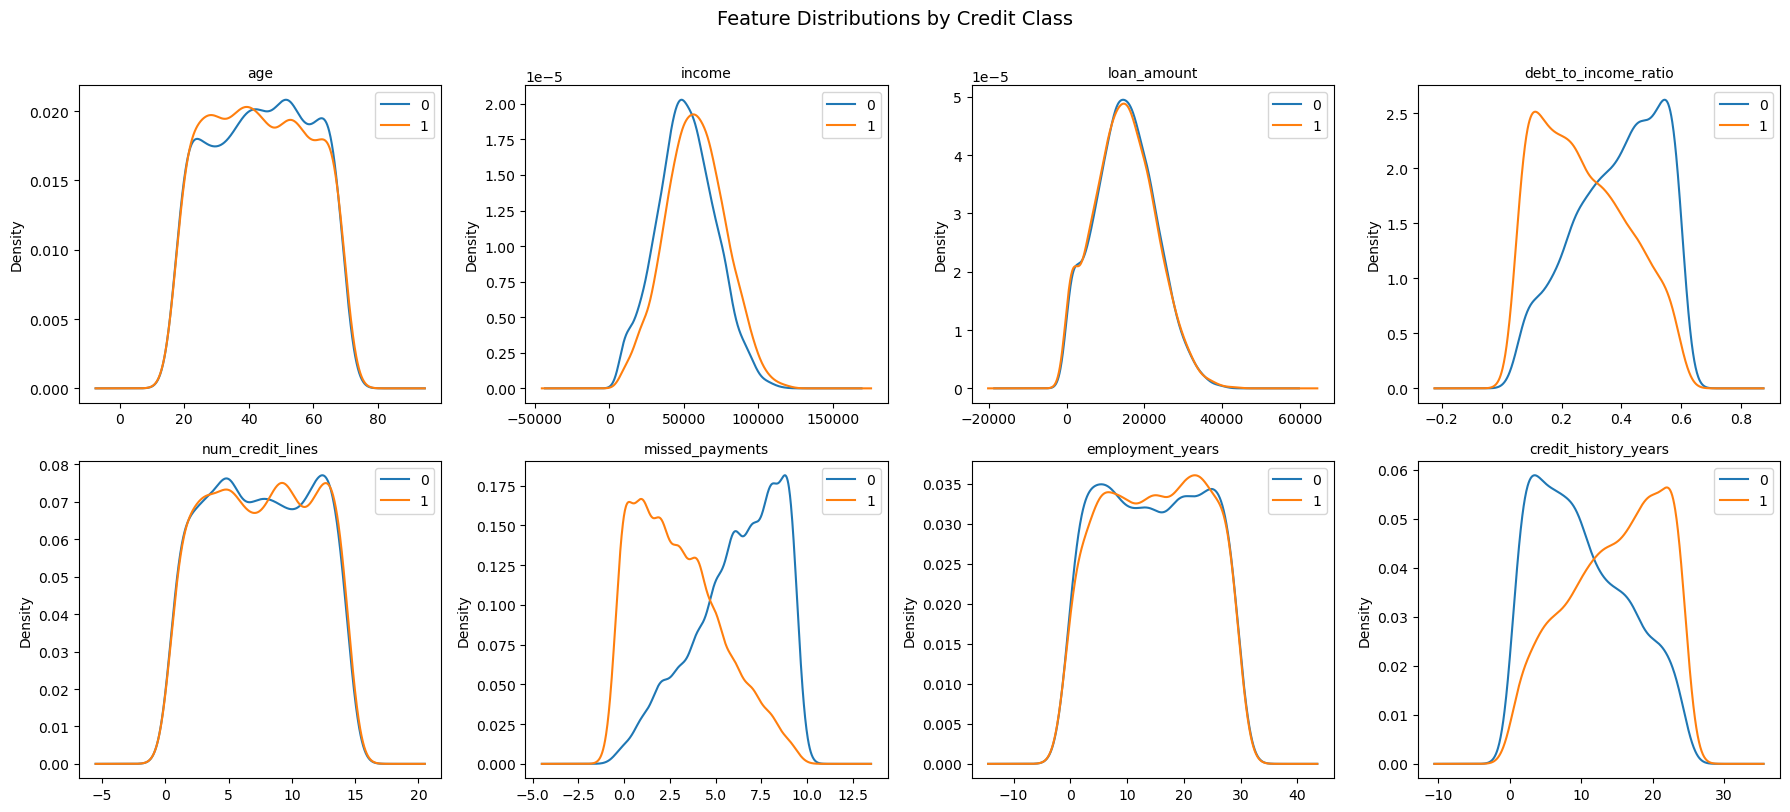

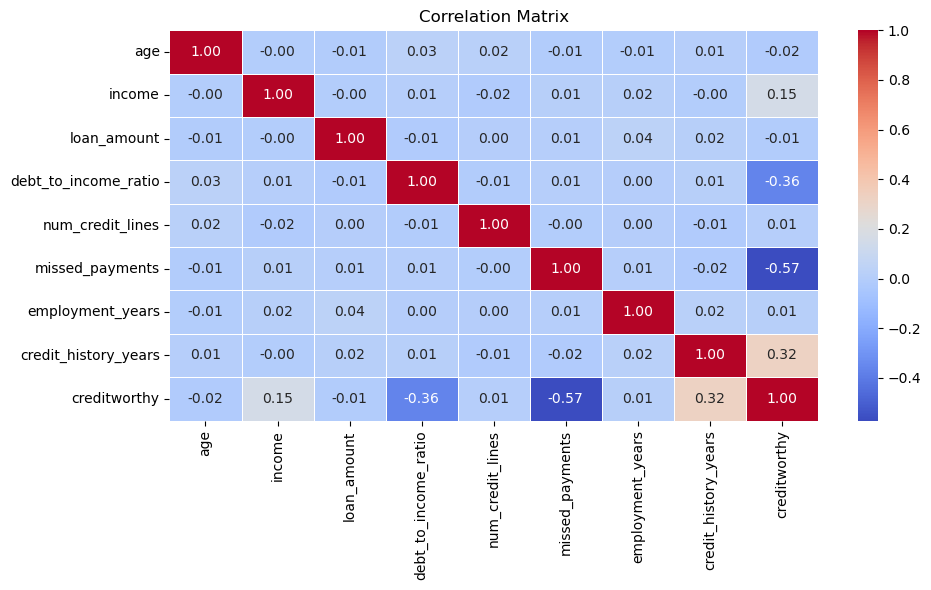


[EDA] Plots saved.

Train size: (4000, 12), Test size: (1000, 12)

────────────────────────────────────────
Model: Logistic Regression
  Accuracy : 0.9020
  F1-Score : 0.8998
  ROC-AUC  : 0.9676
              precision    recall  f1-score   support

  Bad Credit       0.90      0.91      0.90       508
 Good Credit       0.91      0.89      0.90       492

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000


────────────────────────────────────────
Model: Decision Tree
  Accuracy : 0.8560
  F1-Score : 0.8548
  ROC-AUC  : 0.9296
              precision    recall  f1-score   support

  Bad Credit       0.86      0.85      0.86       508
 Good Credit       0.85      0.86      0.85       492

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000


──────────────────────────

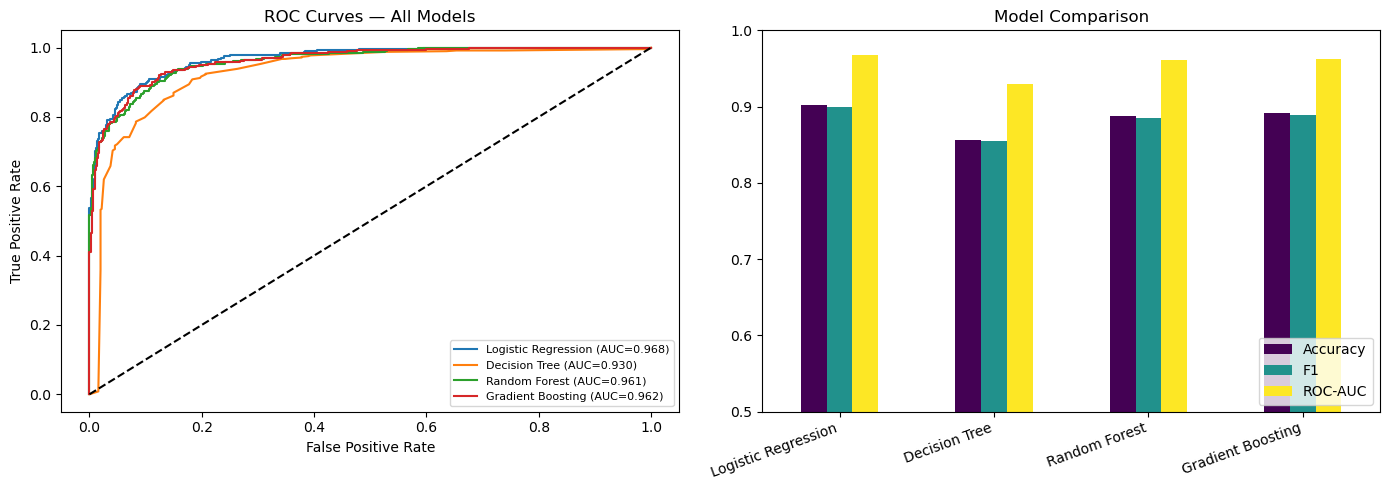


[Training] ROC + comparison plot saved.

✅ Best Model: Logistic Regression (ROC-AUC = 0.9676)


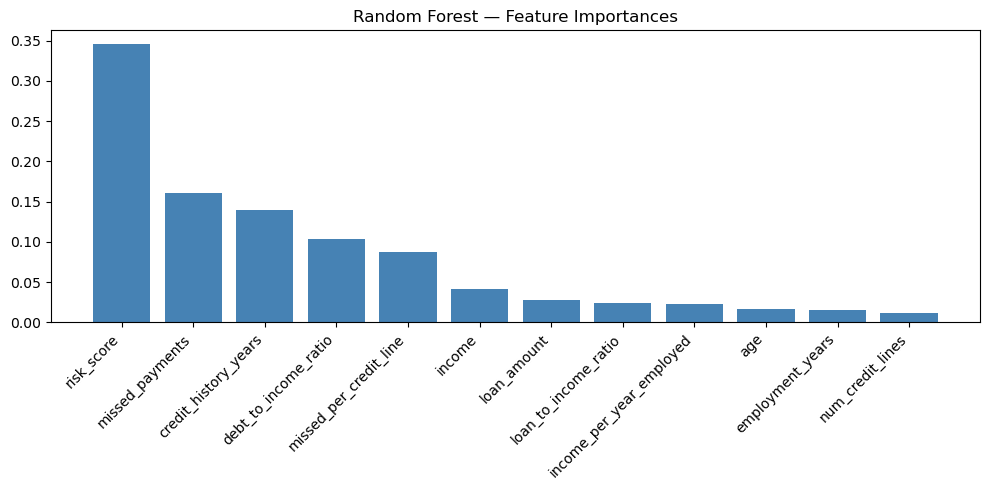

[Feature Importance] Plot saved.

5-Fold CV ROC-AUC: 0.9610 ± 0.0030

✅ All outputs saved. Upload to GitHub as: CodeAlpha_CreditScoringModel


In [2]:
"""
CodeAlpha Internship — Task 1: Credit Scoring Model
Author: [Your Name]
Description: Predicts an individual's creditworthiness using classification algorithms.
Dataset: Simulated financial dataset (replace with real data like Kaggle's Credit Risk Dataset)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, accuracy_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# 1. GENERATE / LOAD DATASET
# ─────────────────────────────────────────────
def generate_dataset(n=5000, seed=42):
    """
    Generates a synthetic credit dataset.
    Replace this function with pd.read_csv('your_data.csv') for real data.
    """
    np.random.seed(seed)
    age           = np.random.randint(18, 70, n)
    income        = np.random.normal(55000, 20000, n).clip(10000, 200000)
    loan_amount   = np.random.normal(15000, 8000, n).clip(1000, 60000)
    debt_to_income= np.random.uniform(0.05, 0.6, n)
    num_credit_lines = np.random.randint(1, 15, n)
    missed_payments  = np.random.randint(0, 10, n)
    employment_years = np.random.randint(0, 30, n)
    credit_history   = np.random.randint(1, 25, n)

    # Credit score formula (higher = better)
    score = (
        0.3 * (income / 200000)
        - 0.4 * (debt_to_income)
        - 0.3 * (missed_payments / 10)
        + 0.2 * (credit_history / 25)
        + np.random.normal(0, 0.05, n)
    )
    label = (score > score.mean()).astype(int)  # 1 = Good credit, 0 = Bad

    df = pd.DataFrame({
        'age': age,
        'income': income.astype(int),
        'loan_amount': loan_amount.astype(int),
        'debt_to_income_ratio': debt_to_income.round(3),
        'num_credit_lines': num_credit_lines,
        'missed_payments': missed_payments,
        'employment_years': employment_years,
        'credit_history_years': credit_history,
        'creditworthy': label
    })
    return df


# ─────────────────────────────────────────────
# 2. EXPLORATORY DATA ANALYSIS
# ─────────────────────────────────────────────
def eda(df):
    print("=" * 55)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 55)
    print(df.describe().T.round(2))
    print(f"\nClass distribution:\n{df['creditworthy'].value_counts()}")

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    features = [c for c in df.columns if c != 'creditworthy']
    for ax, feat in zip(axes.flatten(), features):
        df.groupby('creditworthy')[feat].plot.kde(ax=ax, legend=True)
        ax.set_title(feat, fontsize=10)
        ax.set_xlabel('')
    plt.suptitle('Feature Distributions by Credit Class', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    plt.figure(figsize=(10, 6))
    sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.savefig('correlation_matrix.png', dpi=150)
    plt.show()
    plt.close()
    print("\n[EDA] Plots saved.")


# ─────────────────────────────────────────────
# 3. FEATURE ENGINEERING
# ─────────────────────────────────────────────
def feature_engineering(df):
    df = df.copy()
    df['loan_to_income_ratio']     = df['loan_amount'] / (df['income'] + 1)
    df['missed_per_credit_line']   = df['missed_payments'] / (df['num_credit_lines'] + 1)
    df['income_per_year_employed'] = df['income'] / (df['employment_years'] + 1)
    df['risk_score']               = (
        df['debt_to_income_ratio'] * 0.4
        + df['missed_payments'] / 10 * 0.4
        + df['loan_to_income_ratio'] * 0.2
    )
    return df


# ─────────────────────────────────────────────
# 4. TRAIN / EVALUATE MODELS
# ─────────────────────────────────────────────
def build_pipeline(clf):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', clf)
    ])

def train_and_evaluate(X_train, X_test, y_train, y_test):
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0),
        'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=42),
        'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),
        'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42),
    }

    results = {}
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for name, clf in models.items():
        pipe = build_pipeline(clf)
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)[:, 1]

        acc   = accuracy_score(y_test, y_pred)
        f1    = f1_score(y_test, y_pred)
        auc   = roc_auc_score(y_test, y_prob)
        results[name] = {'Accuracy': acc, 'F1': f1, 'ROC-AUC': auc, 'model': pipe}

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

        print(f"\n{'─'*40}")
        print(f"Model: {name}")
        print(f"  Accuracy : {acc:.4f}")
        print(f"  F1-Score : {f1:.4f}")
        print(f"  ROC-AUC  : {auc:.4f}")
        print(classification_report(y_test, y_pred, target_names=['Bad Credit', 'Good Credit']))

    # ROC Curve
    axes[0].plot([0,1],[0,1],'k--')
    axes[0].set_title('ROC Curves — All Models')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].legend(fontsize=8)

    # Model Comparison Bar
    metrics_df = pd.DataFrame({k: {m: v for m, v in results[k].items() if m != 'model'} for k in results}).T
    metrics_df[['Accuracy','F1','ROC-AUC']].plot(kind='bar', ax=axes[1], colormap='viridis')
    axes[1].set_title('Model Comparison')
    axes[1].set_ylim(0.5, 1.0)
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')
    axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print("\n[Training] ROC + comparison plot saved.")
    return results


# ─────────────────────────────────────────────
# 5. FEATURE IMPORTANCE (Random Forest)
# ─────────────────────────────────────────────
def plot_feature_importance(model, feature_names):
    rf = model.named_steps['clf']
    importances = rf.feature_importances_
    idx = np.argsort(importances)[::-1]

    plt.figure(figsize=(10, 5))
    plt.bar(range(len(importances)), importances[idx], color='steelblue')
    plt.xticks(range(len(importances)), [feature_names[i] for i in idx], rotation=45, ha='right')
    plt.title('Random Forest — Feature Importances')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150)
    plt.show()
    plt.close()
    print("[Feature Importance] Plot saved.")


# ─────────────────────────────────────────────
# 6. MAIN
# ─────────────────────────────────────────────
def main():
    print("=" * 55)
    print("  CodeAlpha — TASK 1: Credit Scoring Model")
    print("=" * 55)

    # Load & engineer data
    df = generate_dataset()
    eda(df)
    df = feature_engineering(df)

    X = df.drop('creditworthy', axis=1)
    y = df['creditworthy']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"\nTrain size: {X_train.shape}, Test size: {X_test.shape}")

    results = train_and_evaluate(X_train, X_test, y_train, y_test)

    best_name = max(results, key=lambda k: results[k]['ROC-AUC'])
    print(f"\n✅ Best Model: {best_name} (ROC-AUC = {results[best_name]['ROC-AUC']:.4f})")

    plot_feature_importance(results['Random Forest']['model'], list(X.columns))

    # Cross-validation on best model
    from sklearn.pipeline import Pipeline
    best_pipe = results[best_name]['model']
    cv_scores = cross_val_score(best_pipe, X, y, cv=5, scoring='roc_auc')
    print(f"\n5-Fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    print("\n✅ All outputs saved. Upload to GitHub as: CodeAlpha_CreditScoringModel")

if __name__ == '__main__':
    main()